# Week 12 Tutorial - Training Best Practices

**How to use this notebook:**
Read one section of `study-guide.md`, then do that section here before moving on.

Each section has:
- A worked example (pre-written - just run it)
- A **DO IT YOURSELF** cell with a follow-up task

---

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

print('PyTorch version:', torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

PyTorch version: 2.8.0+cu126
Device: cuda


---
## Section 1 - Why Training Goes Wrong
### EXAMPLE

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 410kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.95MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


Epoch 1: train=0.1792  val=0.0635
Epoch 2: train=0.0499  val=0.0371
Epoch 3: train=0.0337  val=0.0319
Epoch 4: train=0.0252  val=0.0292
Epoch 5: train=0.0186  val=0.0272
Epoch 6: train=0.0141  val=0.0290
Epoch 7: train=0.0106  val=0.0356
Epoch 8: train=0.0089  val=0.0316
Epoch 9: train=0.0092  val=0.0348
Epoch 10: train=0.0069  val=0.0318


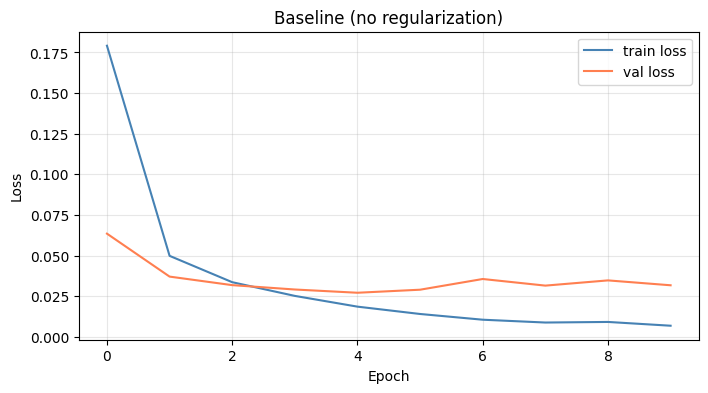

In [2]:
# EXAMPLE: train a CNN on MNIST with no regularization techniques
# Goal: observe overfitting so you know what to fix in later sections

torch.manual_seed(42)

transform = transforms.ToTensor()
train_data = datasets.MNIST(root='data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

# baseline model - no dropout, no batchnorm
class BaselineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64*5*5, 256)
        self.fc2   = nn.Linear(256, 10)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

baseline    = BaselineNet().to(device)
criterion   = nn.CrossEntropyLoss()
optimizer   = optim.Adam(baseline.parameters(), lr=0.001)

baseline_train_losses = []
baseline_val_losses   = []

for epoch in range(10):
    baseline.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = baseline(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    baseline_train_losses.append(np.mean(batch_losses))

    baseline.eval()
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            batch_val.append(criterion(baseline(X_batch), y_batch).item())
    baseline_val_losses.append(np.mean(batch_val))
    print(f'Epoch {epoch+1}: train={baseline_train_losses[-1]:.4f}  val={baseline_val_losses[-1]:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(baseline_train_losses, 'steelblue', label='train loss')
plt.plot(baseline_val_losses,   'coral',     label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline (no regularization)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### DO IT YOURSELF - Section 1

Look at the loss curve from the example above and answer in a comment:
1. Is the model overfitting, underfitting, or neither? How can you tell from the curve?
2. At which epoch does the problem start?
3. What is the gap between train loss and val loss at the final epoch?

In [3]:
# DO IT YOURSELF - Section 1
# Answer in comments:

# 1. Is the model overfitting, underfitting, or neither?
#    This is overfitting, we see train loss  dropping while val loss going up increasing the gap between them

# 2. At which epoch does the problem start?
#   It starts right after Epoch 2

# 3. What is the gap between train and val loss at the final epoch? -0.0249
final_gap = baseline_train_losses[-1] - baseline_val_losses[-1]
print(f'Final gap: {final_gap:.4f}')

Final gap: -0.0249


---
## Section 2 - Dropout
### EXAMPLE

Epoch 1: train=0.2244  val=0.0562
Epoch 2: train=0.0702  val=0.0347
Epoch 3: train=0.0531  val=0.0293
Epoch 4: train=0.0412  val=0.0284
Epoch 5: train=0.0340  val=0.0250
Epoch 6: train=0.0308  val=0.0290
Epoch 7: train=0.0251  val=0.0328
Epoch 8: train=0.0227  val=0.0240
Epoch 9: train=0.0202  val=0.0262
Epoch 10: train=0.0177  val=0.0251


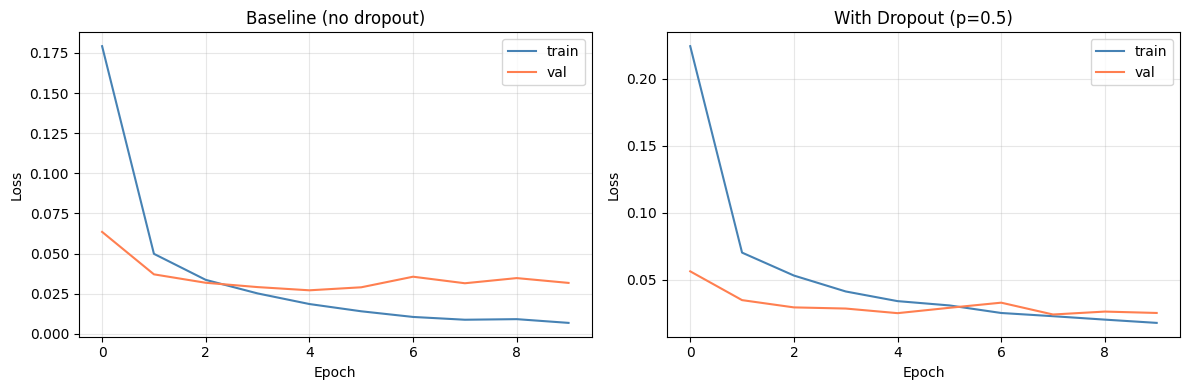

In [4]:
# EXAMPLE: add Dropout to the model and compare loss curves
# Dropout is placed after relu, between linear layers

torch.manual_seed(42)

class DropoutNet(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2   = nn.Conv2d(32, 64, kernel_size=3)
        self.pool    = nn.MaxPool2d(2, 2)
        self.fc1     = nn.Linear(64*5*5, 256)
        self.dropout = nn.Dropout(p=p)   # p = probability of zeroing a neuron
        self.fc2     = nn.Linear(256, 10)
        self.relu    = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)   # randomly zero 50% of neurons during training
        x = self.fc2(x)
        return x

dropout_model   = DropoutNet(p=0.5).to(device)
criterion       = nn.CrossEntropyLoss()
optimizer       = optim.Adam(dropout_model.parameters(), lr=0.001)

dropout_train_losses = []
dropout_val_losses   = []

for epoch in range(10):
    dropout_model.train()   # dropout active
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = dropout_model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    dropout_train_losses.append(np.mean(batch_losses))

    dropout_model.eval()   # dropout off - all neurons active for val
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            batch_val.append(criterion(dropout_model(X_batch), y_batch).item())
    dropout_val_losses.append(np.mean(batch_val))
    print(f'Epoch {epoch+1}: train={dropout_train_losses[-1]:.4f}  val={dropout_val_losses[-1]:.4f}')

# compare baseline vs dropout
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(baseline_train_losses, 'steelblue', label='train')
axes[0].plot(baseline_val_losses,   'coral',     label='val')
axes[0].set_title('Baseline (no dropout)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(dropout_train_losses, 'steelblue', label='train')
axes[1].plot(dropout_val_losses,   'coral',     label='val')
axes[1].set_title('With Dropout (p=0.5)')
axes[1].legend()
axes[1].grid(alpha=0.3)
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
plt.tight_layout()
plt.show()

### DO IT YOURSELF - Section 2

1. Train a new `DropoutNet` with `p=0.2` for 10 epochs
2. Plot its train/val loss alongside the `p=0.5` model from the example
3. Answer in a comment: which p value gives a smaller gap between train and val loss? Why?

Epoch 1: train=0.1979  val=0.0646
Epoch 2: train=0.0610  val=0.0434
Epoch 3: train=0.0432  val=0.0334
Epoch 4: train=0.0324  val=0.0297
Epoch 5: train=0.0266  val=0.0292
Epoch 6: train=0.0220  val=0.0260
Epoch 7: train=0.0181  val=0.0262
Epoch 8: train=0.0155  val=0.0276
Epoch 9: train=0.0126  val=0.0327
Epoch 10: train=0.0112  val=0.0306


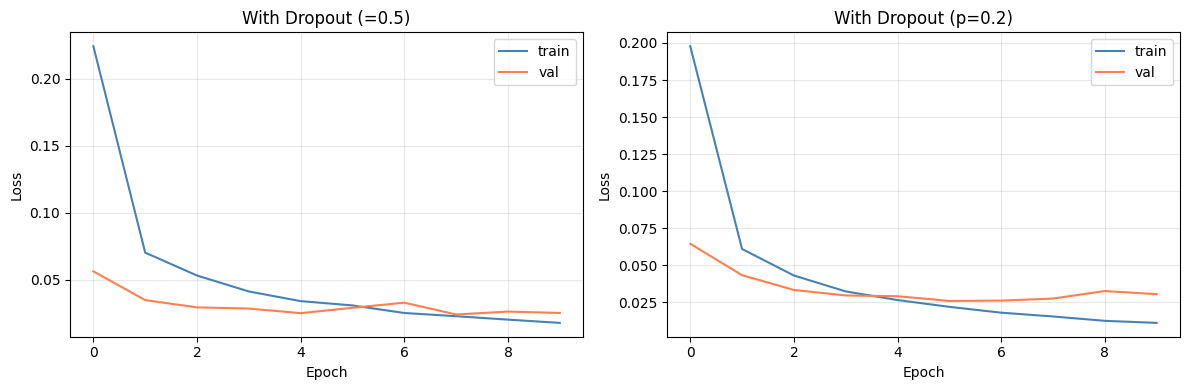

In [7]:
# DO IT YOURSELF - Section 2
# YOUR CODE HERE

# 3. Which p value gives smaller gap between train and val loss? Why?
#    YOUR ANSWER:
dropout_model_2   = DropoutNet(p=0.2).to(device)
optimizer_2     = optim.Adam(dropout_model_2.parameters(), lr=0.001)

dropout_train_losses_2 = []
dropout_val_losses_2   = []

for epoch in range(10):
    dropout_model_2.train()   # dropout active
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_2.zero_grad()
        pred = dropout_model_2(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer_2.step()
        batch_losses.append(loss.item())
    dropout_train_losses_2.append(np.mean(batch_losses))

    dropout_model_2.eval()   # dropout off - all neurons active for val
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            batch_val.append(criterion(dropout_model_2(X_batch), y_batch).item())
    dropout_val_losses_2.append(np.mean(batch_val))
    print(f'Epoch {epoch+1}: train={dropout_train_losses_2[-1]:.4f}  val={dropout_val_losses_2[-1]:.4f}')

# compare baseline vs dropout
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(dropout_train_losses, 'steelblue', label='train')
axes[0].plot(dropout_val_losses,   'coral',     label='val')
axes[0].set_title('With Dropout (=0.5)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(dropout_train_losses_2, 'steelblue', label='train')
axes[1].plot(dropout_val_losses_2,   'coral',     label='val')
axes[1].set_title('With Dropout (p=0.2)')
axes[1].legend()
axes[1].grid(alpha=0.3)
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
plt.tight_layout()
plt.show()

# With 0.2 we see much smaller loss, but gaps are bigger. so its still overfitting meaning not enough neurons are zeroes out
# so that all neuron can learn equally


---
## Section 3 - Batch Normalization
### EXAMPLE

Epoch 1: train=0.0884  val=0.0392
Epoch 2: train=0.0328  val=0.0280
Epoch 3: train=0.0213  val=0.0275
Epoch 4: train=0.0168  val=0.0344
Epoch 5: train=0.0128  val=0.0297
Epoch 6: train=0.0100  val=0.0294
Epoch 7: train=0.0088  val=0.0339
Epoch 8: train=0.0076  val=0.0261
Epoch 9: train=0.0052  val=0.0314
Epoch 10: train=0.0051  val=0.0302


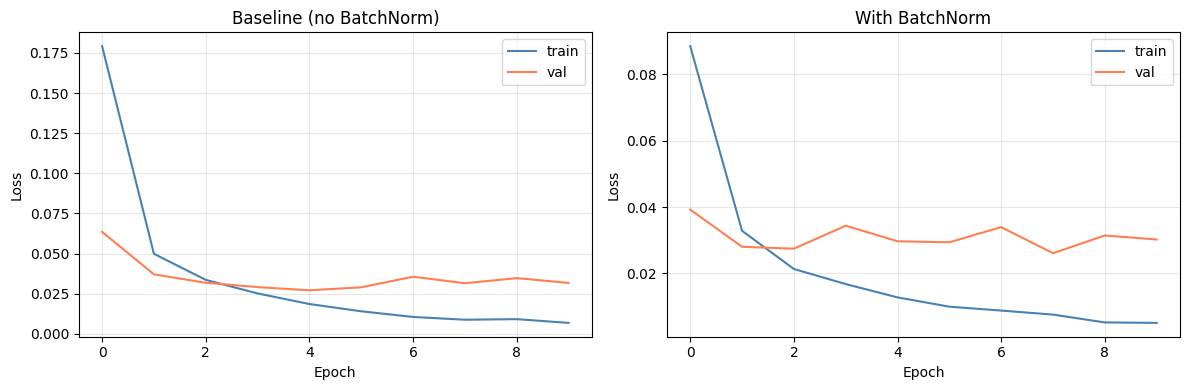

In [8]:
# EXAMPLE: add BatchNorm to the model
# BatchNorm goes between conv/linear and relu: conv -> batchnorm -> relu
# BatchNorm2d is used after Conv2d (num_features = out_channels)
# BatchNorm1d is used after Linear (num_features = output size of linear layer)

torch.manual_seed(42)

class BatchNormNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1   = nn.BatchNorm2d(32)    # 32 = out_channels of conv1
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.bn2   = nn.BatchNorm2d(64)    # 64 = out_channels of conv2
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64*5*5, 256)
        self.bn3   = nn.BatchNorm1d(256)   # 256 = output size of fc1
        self.fc2   = nn.Linear(256, 10)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))   # conv -> bn -> relu -> pool
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.relu(self.bn3(self.fc1(x)))               # linear -> bn -> relu
        x = self.fc2(x)
        return x

bn_model  = BatchNormNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=0.001)

bn_train_losses = []
bn_val_losses   = []

for epoch in range(10):
    bn_model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = bn_model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    bn_train_losses.append(np.mean(batch_losses))

    bn_model.eval()
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            batch_val.append(criterion(bn_model(X_batch), y_batch).item())
    bn_val_losses.append(np.mean(batch_val))
    print(f'Epoch {epoch+1}: train={bn_train_losses[-1]:.4f}  val={bn_val_losses[-1]:.4f}')

# compare baseline vs batchnorm
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(baseline_train_losses, 'steelblue', label='train')
axes[0].plot(baseline_val_losses,   'coral',     label='val')
axes[0].set_title('Baseline (no BatchNorm)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(bn_train_losses, 'steelblue', label='train')
axes[1].plot(bn_val_losses,   'coral',     label='val')
axes[1].set_title('With BatchNorm')
axes[1].legend()
axes[1].grid(alpha=0.3)
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
plt.tight_layout()
plt.show()

### DO IT YOURSELF - Section 3

1. Create a `BatchNormNet` but remove `bn3` (the BatchNorm after fc1) so only the conv layers have BatchNorm
2. Train for 10 epochs and plot train/val loss
3. Answer in a comment: does removing BatchNorm from the linear layer make a visible difference?

Epoch 1: train=0.1086  val=0.0431
Epoch 2: train=0.0421  val=0.0405
Epoch 3: train=0.0303  val=0.0298
Epoch 4: train=0.0237  val=0.0360
Epoch 5: train=0.0201  val=0.0255
Epoch 6: train=0.0147  val=0.0290
Epoch 7: train=0.0136  val=0.0358
Epoch 8: train=0.0090  val=0.0560
Epoch 9: train=0.0100  val=0.0436
Epoch 10: train=0.0085  val=0.0355


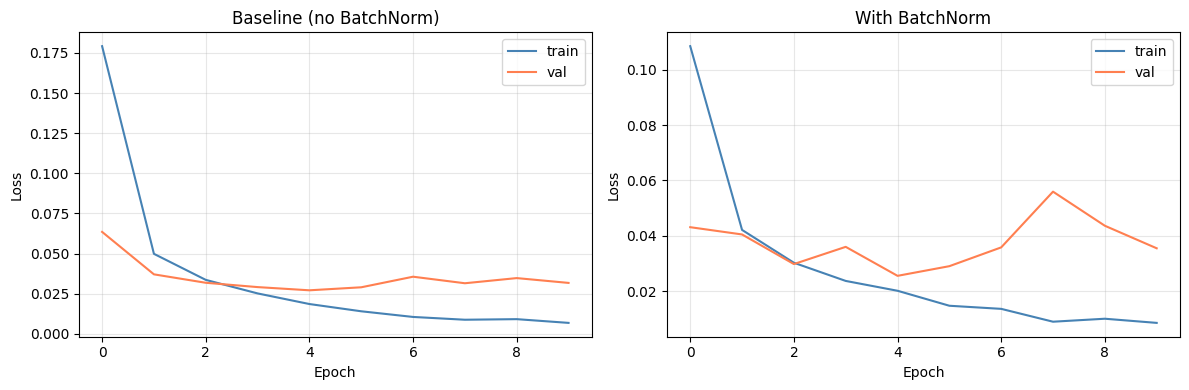

In [9]:
# DO IT YOURSELF - Section 3
# YOUR CODE HERE
torch.manual_seed(42)

class BatchNormNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1   = nn.BatchNorm2d(32)    # 32 = out_channels of conv1
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.bn2   = nn.BatchNorm2d(64)    # 64 = out_channels of conv2
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64*5*5, 256)
        self.fc2   = nn.Linear(256, 10)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))   # conv -> bn -> relu -> pool
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))               # linear -> bn -> relu
        x = self.fc2(x)
        return x

bn_model  = BatchNormNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=0.001)

bn_train_losses = []
bn_val_losses   = []

for epoch in range(10):
    bn_model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = bn_model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    bn_train_losses.append(np.mean(batch_losses))

    bn_model.eval()
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            batch_val.append(criterion(bn_model(X_batch), y_batch).item())
    bn_val_losses.append(np.mean(batch_val))
    print(f'Epoch {epoch+1}: train={bn_train_losses[-1]:.4f}  val={bn_val_losses[-1]:.4f}')

# compare baseline vs batchnorm
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(baseline_train_losses, 'steelblue', label='train')
axes[0].plot(baseline_val_losses,   'coral',     label='val')
axes[0].set_title('Baseline (no BatchNorm)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(bn_train_losses, 'steelblue', label='train')
axes[1].plot(bn_val_losses,   'coral',     label='val')
axes[1].set_title('With BatchNorm')
axes[1].legend()
axes[1].grid(alpha=0.3)
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
plt.tight_layout()
plt.show()

# 3. Does removing BatchNorm from the linear layer make a visible difference?
# YOUR ANSWER: Yes but both models giives very unstable and overfit results
# Does seem like in this case Batchnorm does not work very well. Could be that
# Data is alreadyy good for effective training, and we a speeding it up too much.

---
## Section 4 - Learning Rate Scheduling
### EXAMPLE

Epoch 1: train=0.2250  val=0.0535  lr=0.001000
Epoch 2: train=0.0710  val=0.0347  lr=0.001000
Epoch 3: train=0.0532  val=0.0308  lr=0.001000
Epoch 4: train=0.0411  val=0.0269  lr=0.001000
Epoch 5: train=0.0354  val=0.0262  lr=0.001000
Epoch 6: train=0.0307  val=0.0274  lr=0.001000
Epoch 7: train=0.0254  val=0.0278  lr=0.001000
Epoch 8: train=0.0223  val=0.0275  lr=0.001000
Epoch 9: train=0.0201  val=0.0290  lr=0.001000
Epoch 10: train=0.0121  val=0.0260  lr=0.000500
Epoch 11: train=0.0104  val=0.0273  lr=0.000500
Epoch 12: train=0.0085  val=0.0296  lr=0.000500
Epoch 13: train=0.0078  val=0.0263  lr=0.000500
Epoch 14: train=0.0071  val=0.0267  lr=0.000500
Epoch 15: train=0.0046  val=0.0275  lr=0.000250


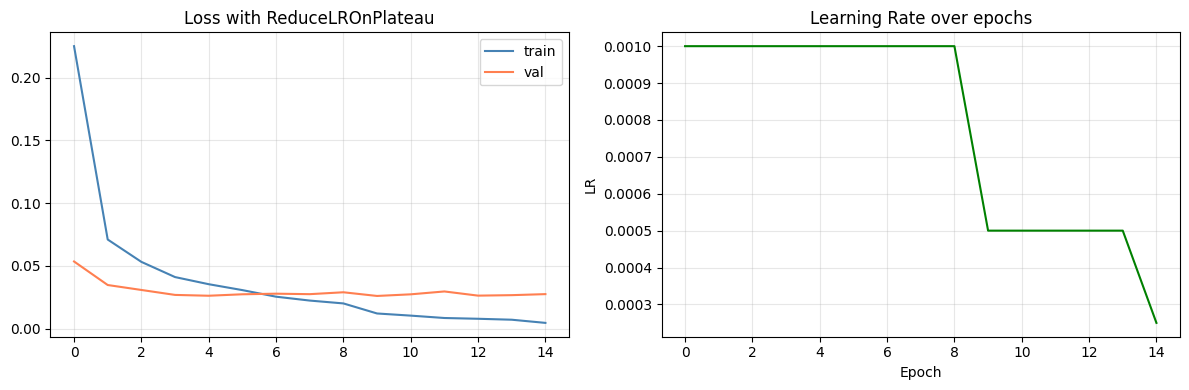

In [10]:
# EXAMPLE: add ReduceLROnPlateau scheduler
# The scheduler watches val loss each epoch and reduces lr if it stops improving
# scheduler.step(val_loss) must be called after computing val loss each epoch

torch.manual_seed(42)

model     = DropoutNet(p=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ReduceLROnPlateau: reduces lr by factor when val loss does not improve for patience epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',      # watching for val loss to go down
    factor=0.5,      # new lr = lr * 0.5
    patience=3       # wait 3 epochs of no improvement before reducing
)

lr_train_losses = []
lr_val_losses   = []
lr_history      = []   # track how lr changes

for epoch in range(15):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    lr_train_losses.append(np.mean(batch_losses))

    model.eval()
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            batch_val.append(criterion(model(X_batch), y_batch).item())
    val_loss = np.mean(batch_val)
    lr_val_losses.append(val_loss)

    current_lr = optimizer.param_groups[0]['lr']   # read current lr
    lr_history.append(current_lr)
    scheduler.step(val_loss)   # pass val loss to scheduler

    print(f'Epoch {epoch+1}: train={lr_train_losses[-1]:.4f}  val={val_loss:.4f}  lr={current_lr:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lr_train_losses, 'steelblue', label='train')
axes[0].plot(lr_val_losses,   'coral',     label='val')
axes[0].set_title('Loss with ReduceLROnPlateau')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(lr_history, 'green')
axes[1].set_title('Learning Rate over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('LR')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### DO IT YOURSELF - Section 4

1. Replace `ReduceLROnPlateau` with `StepLR` (step_size=3, gamma=0.5)
2. Train for 15 epochs, plot the learning rate history
3. Answer in a comment: how does StepLR differ from ReduceLROnPlateau in when it reduces the lr?

Epoch 1: train=0.2321  val=0.0570  lr=0.001000
Epoch 2: train=0.0777  val=0.0350  lr=0.001000
Epoch 3: train=0.0579  val=0.0288  lr=0.001000
Epoch 4: train=0.0479  val=0.0287  lr=0.001000
Epoch 5: train=0.0389  val=0.0250  lr=0.001000
Epoch 6: train=0.0261  val=0.0216  lr=0.000500
Epoch 7: train=0.0203  val=0.0212  lr=0.000500
Epoch 8: train=0.0193  val=0.0225  lr=0.000500
Epoch 9: train=0.0180  val=0.0224  lr=0.000500
Epoch 10: train=0.0149  val=0.0239  lr=0.000500
Epoch 11: train=0.0112  val=0.0194  lr=0.000250
Epoch 12: train=0.0096  val=0.0213  lr=0.000250
Epoch 13: train=0.0082  val=0.0203  lr=0.000250
Epoch 14: train=0.0080  val=0.0211  lr=0.000250
Epoch 15: train=0.0080  val=0.0206  lr=0.000250


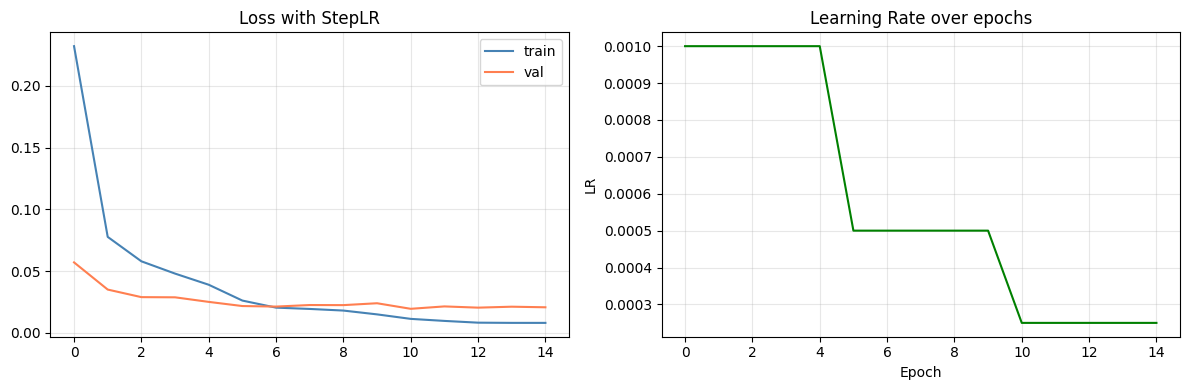

In [ ]:
# DO IT YOURSELF - Section 4
# YOUR CODE HERE
# Note: StepLR uses scheduler.step() with no argument, not scheduler.step(val_loss)

model2     = DropoutNet(p=0.5).to(device)

optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

# ReduceLROnPlateau: reduces lr by factor when val loss does not improve for patience epochs
scheduler2 = torch.optim.lr_scheduler.StepLR(
    optimizer2,
    step_size=5,
    gamma=0.5
)

lr_train_losses = []
lr_val_losses   = []
lr_history      = []   # track how lr changes

for epoch in range(15):
    model2.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer2.zero_grad()
        pred = model2(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer2.step()
        batch_losses.append(loss.item())
    lr_train_losses.append(np.mean(batch_losses))

    model2.eval()
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            batch_val.append(criterion(model2(X_batch), y_batch).item())
    val_loss = np.mean(batch_val)
    lr_val_losses.append(val_loss)

    current_lr = optimizer2.param_groups[0]['lr']   # read current lr
    lr_history.append(current_lr)
    scheduler2.step()   # pass val loss to scheduler

    print(f'Epoch {epoch+1}: train={lr_train_losses[-1]:.4f}  val={val_loss:.4f}  lr={current_lr:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lr_train_losses, 'steelblue', label='train')
axes[0].plot(lr_val_losses,   'coral',     label='val')
axes[0].set_title('Loss with StepLR')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(lr_history, 'green')
axes[1].set_title('Learning Rate over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('LR')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. How does StepLR differ from ReduceLROnPlateau?
#    YOUR ANSWER:
# LR reduction happens much more earlier and consistent pattern because thats what step LR does 
# Mean while is based on whether loss is improving or not so you see reduction in lr much later on

---
## Section 5 - Early Stopping
### EXAMPLE

Epoch 1: val=0.0550  improved - saved
Epoch 2: val=0.0342  improved - saved
Epoch 3: val=0.0319  improved - saved
Epoch 4: val=0.0261  improved - saved
Epoch 5: val=0.0250  improved - saved
Epoch 6: val=0.0263  no improvement (1/5)
Epoch 7: val=0.0288  no improvement (2/5)
Epoch 8: val=0.0238  improved - saved
Epoch 9: val=0.0251  no improvement (1/5)
Epoch 10: val=0.0267  no improvement (2/5)
Epoch 11: val=0.0295  no improvement (3/5)
Epoch 12: val=0.0357  no improvement (4/5)
Epoch 13: val=0.0289  no improvement (5/5)
Early stopping triggered at epoch 13
Restored best model with val loss: 0.0238


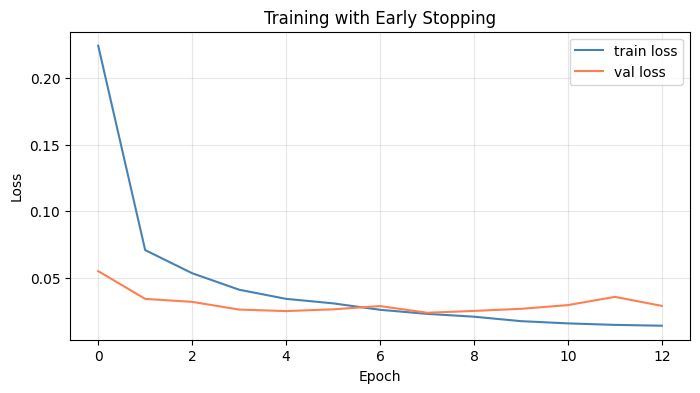

In [14]:
# EXAMPLE: implement early stopping
# Saves best weights when val loss improves, stops when it does not improve for patience epochs
# torch.save saves model weights to a file
# model.load_state_dict loads them back after training stops

torch.manual_seed(42)

model     = DropoutNet(p=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_loss = float('inf')   # infinity so any loss is better on epoch 1
patience      = 5              # stop if no improvement for 5 epochs
no_improve    = 0

es_train_losses = []
es_val_losses   = []

for epoch in range(50):   # set high - early stopping will end it early
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    es_train_losses.append(np.mean(batch_losses))

    model.eval()
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            batch_val.append(criterion(model(X_batch), y_batch).item())
    val_loss = np.mean(batch_val)
    es_val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), 'best_model.pt')   # save best weights
        print(f'Epoch {epoch+1}: val={val_loss:.4f}  improved - saved')
    else:
        no_improve += 1
        print(f'Epoch {epoch+1}: val={val_loss:.4f}  no improvement ({no_improve}/{patience})')

    if no_improve >= patience:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break

# restore best weights
model.load_state_dict(torch.load('best_model.pt'))
print(f'Restored best model with val loss: {best_val_loss:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(es_train_losses, 'steelblue', label='train loss')
plt.plot(es_val_losses,   'coral',     label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training with Early Stopping')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### DO IT YOURSELF - Section 5

1. Change patience to 3 and rerun early stopping
2. Change patience to 10 and rerun
3. Answer in a comment: at which patience does training stop earliest? What is the tradeoff between low and high patience?

In [15]:
torch.manual_seed(42)

criterion = nn.CrossEntropyLoss()

model_1     = DropoutNet(p=0.5).to(device)
optimizer_1 = optim.Adam(model_1.parameters(), lr=0.001)

best_val_loss_1 = float('inf')   # infinity so any loss is better on epoch 1
patience_1      = 3              # stop if no improvement for 5 epochs
no_improve_1    = 0

es_train_losses_1 = []
es_val_losses_1   = []

for epoch in range(50):   # set high - early stopping will end it early
    model_1.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_1.zero_grad()
        pred = model_1(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer_1.step()
        batch_losses.append(loss.item())
    es_train_losses_1.append(np.mean(batch_losses))

    model_1.eval()
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            batch_val.append(criterion(model_1(X_batch), y_batch).item())
    val_loss = np.mean(batch_val)
    es_val_losses_1.append(val_loss)

    if val_loss < best_val_loss_1:
        best_val_loss_1 = val_loss
        no_improve_1    = 0
        torch.save(model_1.state_dict(), 'best_model_1.pt')   # save best weights
        print(f'Epoch {epoch+1}: val={val_loss:.4f}  improved - saved')
    else:
        no_improve_1 += 1
        print(f'Epoch {epoch+1}: val={val_loss:.4f}  no improvement ({no_improve_1}/{patience_1})')

    if no_improve_1 >= patience_1 :
        print(f'Early stopping triggered at epoch {epoch+1}')
        break

# restore best weights
model_1.load_state_dict(torch.load('best_model_1.pt'))
print(f'Restored best model with val loss: {best_val_loss_1:.4f}')

Epoch 1: val=0.0566  improved - saved
Epoch 2: val=0.0321  improved - saved
Epoch 3: val=0.0295  improved - saved
Epoch 4: val=0.0271  improved - saved
Epoch 5: val=0.0276  no improvement (1/3)
Epoch 6: val=0.0274  no improvement (2/3)
Epoch 7: val=0.0281  no improvement (3/3)
Early stopping triggered at epoch 7
Restored best model with val loss: 0.0271


In [16]:
torch.manual_seed(42)

model_2     = DropoutNet(p=0.5).to(device)
optimizer_2 = optim.Adam(model_2.parameters(), lr=0.001)

best_val_loss_2 = float('inf')
patience_2      = 10
no_improve_2    = 0

es_train_losses_2 = []
es_val_losses_2   = []

for epoch in range(50):
    model_2.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_2.zero_grad()
        pred = model_2(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer_2.step()
        batch_losses.append(loss.item())
    es_train_losses_2.append(np.mean(batch_losses))

    model_2.eval()
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            batch_val.append(criterion(model_2(X_batch), y_batch).item())
    val_loss = np.mean(batch_val)
    es_val_losses_2.append(val_loss)

    if val_loss < best_val_loss_2:
        best_val_loss_2 = val_loss
        no_improve_2    = 0
        torch.save(model_2.state_dict(), 'best_model_2.pt')
        print(f'Epoch {epoch+1}: val={val_loss:.4f}  improved - saved')
    else:
        no_improve_2 += 1
        print(f'Epoch {epoch+1}: val={val_loss:.4f}  no improvement ({no_improve_2}/{patience_2})')

    if no_improve_2 >= patience_2:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break

model_2.load_state_dict(torch.load('best_model_2.pt'))
print(f'Restored best model with val loss: {best_val_loss_2:.4f}')

Epoch 1: val=0.0575  improved - saved
Epoch 2: val=0.0349  improved - saved
Epoch 3: val=0.0311  improved - saved
Epoch 4: val=0.0281  improved - saved
Epoch 5: val=0.0242  improved - saved
Epoch 6: val=0.0272  no improvement (1/10)
Epoch 7: val=0.0264  no improvement (2/10)
Epoch 8: val=0.0258  no improvement (3/10)
Epoch 9: val=0.0257  no improvement (4/10)
Epoch 10: val=0.0295  no improvement (5/10)
Epoch 11: val=0.0282  no improvement (6/10)
Epoch 12: val=0.0277  no improvement (7/10)
Epoch 13: val=0.0274  no improvement (8/10)
Epoch 14: val=0.0310  no improvement (9/10)
Epoch 15: val=0.0264  no improvement (10/10)
Early stopping triggered at epoch 15
Restored best model with val loss: 0.0242


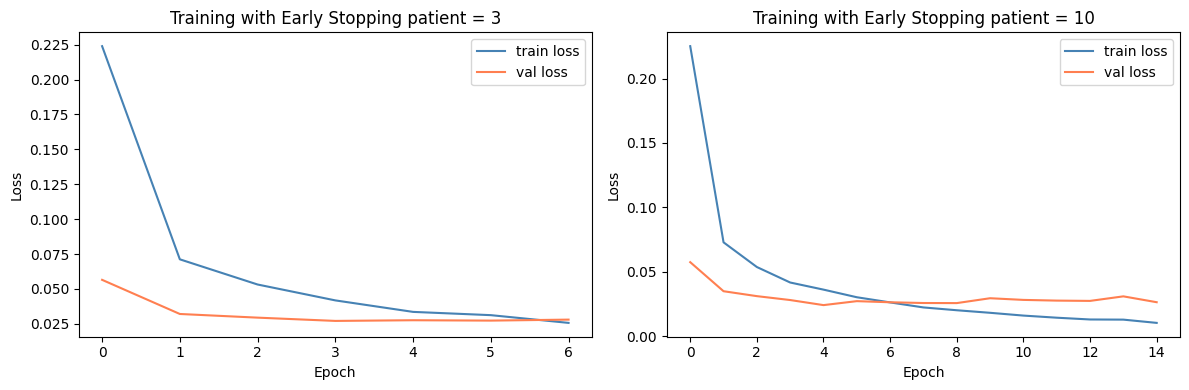

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(es_train_losses_1, 'steelblue', label='train loss')
axes[0].plot(es_val_losses_1,   'coral',     label='val loss')
axes[0].set_title('Training with Early Stopping patient = 3')
axes[0].legend()
axes[1].plot(es_train_losses_2, 'steelblue', label='train loss')
axes[1].plot(es_val_losses_2,   'coral',     label='val loss')
axes[1].set_title('Training with Early Stopping patient = 10')
axes[1].legend()
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
plt.tight_layout()
plt.show()

# Patient 3 stop earliest. When choosing smaller patient value, you end early to prevent model from overfitting, but 
# having too big may not save model at its best because it takes longer step to stop

---
## Section 6 - Weights & Biases
### EXAMPLE

In [10]:
# EXAMPLE: log training metrics to W&B
# First time: wandb.login() will open a browser to authenticate
# After that, runs are tracked at wandb.ai

# pip install wandb   (run this once if not installed)

import wandb
import os
os.environ['WANDB_MODE'] = 'offline'

torch.manual_seed(42)

#wandb.login()

# wandb.init starts a new run and logs the hyperparameters
wandb.init(
    project='week12-mnist',
    config={
        'learning_rate': 0.001,
        'epochs': 10,
        'batch_size': 64,
        'dropout': 0.5
    }
)

model     = DropoutNet(p=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    model.eval()
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            batch_val.append(criterion(model(X_batch), y_batch).item())
    val_loss = np.mean(batch_val)

    # log metrics to W&B after each epoch
    wandb.log({
        'train_loss': train_loss,
        'val_loss':   val_loss,
        'epoch':      epoch
    })

    print(f'Epoch {epoch+1}: train={train_loss:.4f}  val={val_loss:.4f}')

wandb.finish()   # marks the run as complete in W&B dashboard
print('Run logged to wandb.ai')

epoch,▁▂▄▅▇█
train_loss,█▂▂▁▁▁
val_accuracy,▁▅▇▇██
val_loss,█▃▂▁▁▁
epoch,5
train_loss,0.03087
val_accuracy,0.9908
val_loss,0.02779


Epoch 1: train=0.2241  val=0.0573
Epoch 2: train=0.0707  val=0.0327
Epoch 3: train=0.0536  val=0.0306
Epoch 4: train=0.0410  val=0.0270
Epoch 5: train=0.0348  val=0.0252
Epoch 6: train=0.0297  val=0.0249
Epoch 7: train=0.0254  val=0.0287
Epoch 8: train=0.0229  val=0.0246
Epoch 9: train=0.0195  val=0.0297
Epoch 10: train=0.0180  val=0.0264


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▃▂▂▂▁▁▁▁▁
val_loss,█▃▂▂▁▁▂▁▂▁
epoch,9
train_loss,0.01801
val_loss,0.02636


Run logged to wandb.ai


### DO IT YOURSELF - Section 6

1. Add accuracy logging to the W&B run above
2. After each epoch compute test accuracy (correct / total) and log it alongside loss:
   `wandb.log({'train_loss': ..., 'val_loss': ..., 'val_accuracy': ...})`
3. Open wandb.ai and take a screenshot of your run's charts

In [11]:
# DO IT YOURSELF - Section 6
# YOUR CODE HERE
# Hint: compute accuracy inside model.eval() block after computing val_loss
# correct = (preds == y_batch).sum().item()
# total   = y_batch.size(0)

# pip install wandb   (run this once if not installed)

torch.manual_seed(42)

#wandb.login()

# wandb.init starts a new run and logs the hyperparameters
wandb.init(
    project='week12-mnist',
    config={
        'learning_rate': 0.001,
        'epochs': 10,
        'batch_size': 64,
        'dropout': 0.5
    }
)

model     = DropoutNet(p=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    total = 0
    correct = 0
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    model.eval()
    batch_val = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)  # get index of highest logit
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
            batch_val.append(criterion(outputs, y_batch).item())
    val_loss = np.mean(batch_val)
    val_accuracy = correct / total

    # log metrics to W&B after each epoch
    wandb.log({
        'train_loss': train_loss,
        'val_loss':   val_loss,
        'epoch':      epoch,
        'val_accuracy': val_accuracy
    })

    print(f'Epoch {epoch+1}: train={train_loss:.4f}  val={val_loss:.4f}')

wandb.finish()   # marks the run as complete in W&B dashboard
print('Run logged to wandb.ai')

# skipping step 3

Epoch 1: train=0.2243  val=0.0580
Epoch 2: train=0.0714  val=0.0333
Epoch 3: train=0.0531  val=0.0310
Epoch 4: train=0.0413  val=0.0306
Epoch 5: train=0.0343  val=0.0260
Epoch 6: train=0.0301  val=0.0266
Epoch 7: train=0.0248  val=0.0287
Epoch 8: train=0.0219  val=0.0257
Epoch 9: train=0.0194  val=0.0283
Epoch 10: train=0.0173  val=0.0317


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▃▂▂▂▁▁▁▁▁
val_accuracy,▁▆▆▇██▇███
val_loss,█▃▂▂▁▁▂▁▂▂
epoch,9
train_loss,0.01726
val_accuracy,0.9919
val_loss,0.03166


Run logged to wandb.ai


---
## Section 7 - Putting It All Together
### EXAMPLE

Epoch 1: train=0.1165  val=0.0450  acc=0.9860  lr=0.001000  saved
Epoch 2: train=0.0501  val=0.0297  acc=0.9907  lr=0.001000  saved
Epoch 3: train=0.0383  val=0.0269  acc=0.9920  lr=0.001000  saved
Epoch 4: train=0.0290  val=0.0245  acc=0.9923  lr=0.001000  saved
Epoch 5: train=0.0248  val=0.0229  acc=0.9927  lr=0.001000  saved
Epoch 6: train=0.0231  val=0.0252  acc=0.9919  lr=0.001000  (1/5)
Epoch 7: train=0.0185  val=0.0250  acc=0.9919  lr=0.001000  (2/5)
Epoch 8: train=0.0179  val=0.0253  acc=0.9918  lr=0.001000  (3/5)
Epoch 9: train=0.0142  val=0.0263  acc=0.9926  lr=0.000500  (4/5)
Epoch 10: train=0.0099  val=0.0228  acc=0.9930  lr=0.000500  saved
Epoch 11: train=0.0068  val=0.0229  acc=0.9936  lr=0.000500  (1/5)
Epoch 12: train=0.0063  val=0.0232  acc=0.9930  lr=0.000500  (2/5)
Epoch 13: train=0.0055  val=0.0217  acc=0.9941  lr=0.000500  saved
Epoch 14: train=0.0048  val=0.0233  acc=0.9936  lr=0.000500  (1/5)
Epoch 15: train=0.0048  val=0.0229  acc=0.9934  lr=0.000500  (2/5)
Epoc

train_loss,█▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_accuracy,▁▅▆▆▇▆▆▆▇▇█▇██▇▇▆█
val_loss,█▃▃▂▁▂▂▂▂▁▁▁▁▁▁▂▂▁
train_loss,0.00295
val_accuracy,0.9936
val_loss,0.02325


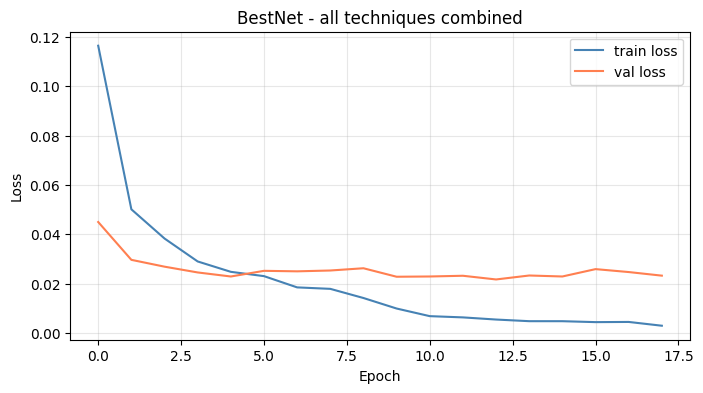

In [12]:
# EXAMPLE: full model combining Dropout + BatchNorm + LR scheduling + early stopping + W&B

torch.manual_seed(42)

class BestNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1     = nn.BatchNorm2d(32)
        self.conv2   = nn.Conv2d(32, 64, kernel_size=3)
        self.bn2     = nn.BatchNorm2d(64)
        self.pool    = nn.MaxPool2d(2, 2)
        self.fc1     = nn.Linear(64*5*5, 256)
        self.bn3     = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2     = nn.Linear(256, 10)
        self.relu    = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.relu(self.bn3(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model     = BestNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

best_val_loss = float('inf')
patience      = 5
no_improve    = 0

wandb.init(project='week12-mnist', config={
    'model': 'BestNet',
    'dropout': 0.5,
    'lr': 0.001,
    'scheduler': 'ReduceLROnPlateau'
})

best_train_losses = []
best_val_losses   = []

for epoch in range(50):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)
    best_train_losses.append(train_loss)

    model.eval()
    batch_val = []
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred  = model(X_batch)
            batch_val.append(criterion(pred, y_batch).item())
            preds  = torch.argmax(pred, dim=1)
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)
    val_loss = np.mean(batch_val)
    val_acc  = correct / total
    best_val_losses.append(val_loss)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    wandb.log({'train_loss': train_loss, 'val_loss': val_loss, 'val_accuracy': val_acc})

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f'Epoch {epoch+1}: train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.4f}  lr={current_lr:.6f}  saved')
    else:
        no_improve += 1
        print(f'Epoch {epoch+1}: train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.4f}  lr={current_lr:.6f}  ({no_improve}/{patience})')

    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

model.load_state_dict(torch.load('best_model.pt'))
wandb.finish()

plt.figure(figsize=(8, 4))
plt.plot(best_train_losses, 'steelblue', label='train loss')
plt.plot(best_val_losses,   'coral',     label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BestNet - all techniques combined')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### DO IT YOURSELF - Section 7

1. Add a third conv layer to `BestNet` with `padding=1` to keep spatial size (use `nn.Conv2d(64, 128, kernel_size=3, padding=1)` and `nn.BatchNorm2d(128)` after it)
2. Update `fc1` input size to match the new flatten size
3. Train with all techniques and compare accuracy to the 2-conv BestNet from the example
4. Answer in a comment: did adding the third conv layer improve or hurt performance?

Epoch 1: train=0.1066  val=0.0310  acc=0.9902  lr=0.001000  saved
Epoch 2: train=0.0439  val=0.0269  acc=0.9911  lr=0.001000  saved
Epoch 3: train=0.0339  val=0.0236  acc=0.9929  lr=0.001000  saved
Epoch 4: train=0.0273  val=0.0222  acc=0.9936  lr=0.001000  saved
Epoch 5: train=0.0241  val=0.0241  acc=0.9927  lr=0.001000  (1/5)
Epoch 6: train=0.0187  val=0.0214  acc=0.9932  lr=0.001000  saved
Epoch 7: train=0.0173  val=0.0237  acc=0.9939  lr=0.001000  (1/5)
Epoch 8: train=0.0155  val=0.0245  acc=0.9930  lr=0.001000  (2/5)
Epoch 9: train=0.0152  val=0.0238  acc=0.9936  lr=0.001000  (3/5)
Epoch 10: train=0.0114  val=0.0220  acc=0.9934  lr=0.000500  (4/5)
Epoch 11: train=0.0055  val=0.0223  acc=0.9937  lr=0.000500  (5/5)
Early stopping at epoch 11


train_loss,█▄▃▃▂▂▂▂▂▁▁
val_accuracy,▁▃▆▇▆▇█▆▇▇█
val_loss,█▅▃▂▃▁▃▃▃▁▂
train_loss,0.00551
val_accuracy,0.9937
val_loss,0.02229


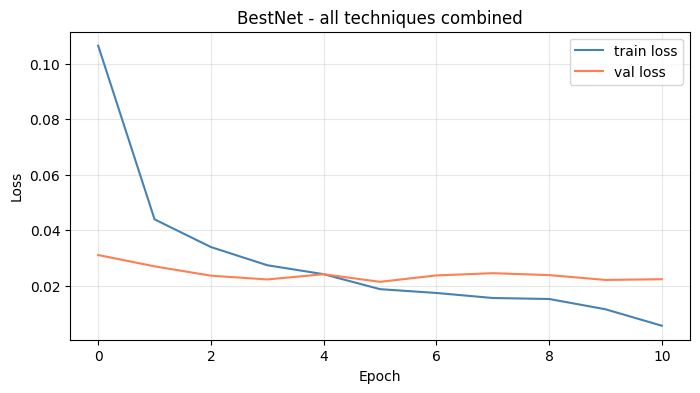

In [ ]:
# DO IT YOURSELF - Section 7
# YOUR CODE HERE
torch.manual_seed(42)

# input_size = (1, 28, 28)
class BestNet_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1     = nn.BatchNorm2d(32)
        self.conv2   = nn.Conv2d(32, 64, kernel_size=3) 
        self.bn2     = nn.BatchNorm2d(64)
        self.conv3   = nn.Conv2d(64, 128, kernel_size=3)
        self.bn3     = nn.BatchNorm2d(128)
        self.pool    = nn.MaxPool2d(2, 2)
        self.fc1     = nn.Linear(128*3*3, 256)
        self.bn4     = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2     = nn.Linear(256, 10)
        self.relu    = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x)))) # (32, 26, 26) -> (32, 13, 13)
        x = self.pool(self.relu(self.bn2(self.conv2(x)))) # (64, 11, 11) -> (64, 5, 5)
        x = self.relu(self.bn3(self.conv3(x))) # (128, 3, 3)
        x = torch.flatten(x, 1) # (128 * 3 * 3) = 1152
        x = self.relu(self.bn4(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model     = BestNet_2().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

best_val_loss = float('inf')
patience      = 5
no_improve    = 0

wandb.init(project='week12-mnist', config={
    'model': 'BestNet',
    'dropout': 0.5,
    'lr': 0.001,
    'scheduler': 'ReduceLROnPlateau'
})

best_train_losses = []
best_val_losses   = []

for epoch in range(50):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)
    best_train_losses.append(train_loss)

    model.eval()
    batch_val = []
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred  = model(X_batch)
            batch_val.append(criterion(pred, y_batch).item())
            preds  = torch.argmax(pred, dim=1)
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)
    val_loss = np.mean(batch_val)
    val_acc  = correct / total
    best_val_losses.append(val_loss)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    wandb.log({'train_loss': train_loss, 'val_loss': val_loss, 'val_accuracy': val_acc})

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f'Epoch {epoch+1}: train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.4f}  lr={current_lr:.6f}  saved')
    else:
        no_improve += 1
        print(f'Epoch {epoch+1}: train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.4f}  lr={current_lr:.6f}  ({no_improve}/{patience})')

    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

model.load_state_dict(torch.load('best_model.pt'))
wandb.finish()

plt.figure(figsize=(8, 4))
plt.plot(best_train_losses, 'steelblue', label='train loss')
plt.plot(best_val_losses,   'coral',     label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BestNet - all techniques combined')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4. Did adding the third conv layer improve or hurt performance?
#    YOUR ANSWER:
"""
2 conv layer
train_loss	0.00295
val_accuracy	0.9936
val_loss	0.02325

3 conv layer
train_loss	0.00551
val_accuracy	0.9937
val_loss	0.0222

Slightly is increased in accuracy and less overfitting
"""

---
## CAPSTONE - CIFAR-10

CIFAR-10 is a dataset of 32x32 color images across 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck). Unlike MNIST, images are RGB (3 channels) and much harder to classify.

Loading CIFAR-10:
```python
transform  = transforms.ToTensor()
train_data = datasets.CIFAR10(root='data', train=True,  download=True, transform=transform)
test_data  = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)
```

Key differences from MNIST:
- Images are (3, 32, 32) not (1, 28, 28) — set `in_channels=3` on first Conv2d
- 10 classes — same as MNIST so output layer stays the same
- Labels are already torch.long, no subtraction needed

Your task:
1. Load CIFAR-10 with DataLoader
2. Design your own CNN architecture (remember in_channels=3 for first conv layer)
3. Track shapes before writing the model
4. Add Dropout, BatchNorm, LR scheduling, and early stopping
5. Log all metrics to W&B
6. Report final test accuracy
7. Written answer: CIFAR-10 is harder than MNIST — what accuracy did you get and why do you think color images are harder to classify?

In [27]:
# CAPSTONE
# YOUR CODE HERE
torch.manual_seed(42)

# input (3, 32, 32)
class CifarNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 32, kernel_size=3)
        self.bn1     = nn.BatchNorm2d(32)
        self.conv2   = nn.Conv2d(32, 64, kernel_size=3) 
        self.bn2     = nn.BatchNorm2d(64)
        self.conv3   = nn.Conv2d(64, 128, kernel_size=3)
        self.bn3     = nn.BatchNorm2d(128)
        self.pool    = nn.MaxPool2d(2, 2)
        self.fc1     = nn.Linear(128*4*4, 256)
        self.bn4     = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2     = nn.Linear(256, 10)
        self.relu    = nn.ReLU()
        self.drop_conv = nn.Dropout2d(p=0.2) 
    
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.drop_conv(x)
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.drop_conv(x)
        x = self.relu(self.bn3(self.conv3(x))) 
        x = self.drop_conv(x)
        x = torch.flatten(x, 1) 
        x = self.relu(self.bn4(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [22]:
transform  = transforms.ToTensor()

train_data = datasets.CIFAR10(root='data', train=True,  download=True, transform=transform)
test_data  = datasets.CIFAR10(root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

train_loss,█▃▁
val_accuracy,▁▅█
val_loss,█▄▁
train_loss,1.43263
val_accuracy,0.5633
val_loss,1.22459


Epoch 1: train=1.8190  val=1.4696  acc=0.4897  lr=0.000100  saved
Epoch 2: train=1.5415  val=1.3035  acc=0.5397  lr=0.000100  saved
Epoch 3: train=1.4324  val=1.2071  acc=0.5732  lr=0.000100  saved
Epoch 4: train=1.3544  val=1.1229  acc=0.6028  lr=0.000100  saved
Epoch 5: train=1.2959  val=1.0846  acc=0.6127  lr=0.000100  saved
Epoch 6: train=1.2434  val=1.0332  acc=0.6377  lr=0.000100  saved
Epoch 7: train=1.2062  val=1.0078  acc=0.6475  lr=0.000100  saved
Epoch 8: train=1.1737  val=0.9682  acc=0.6596  lr=0.000100  saved
Epoch 9: train=1.1435  val=0.9479  acc=0.6684  lr=0.000100  saved
Epoch 10: train=1.1079  val=0.9278  acc=0.6772  lr=0.000100  saved
Epoch 11: train=1.0856  val=0.9051  acc=0.6856  lr=0.000100  saved
Epoch 12: train=1.0642  val=0.8973  acc=0.6898  lr=0.000100  saved
Epoch 13: train=1.0404  val=0.8836  acc=0.6925  lr=0.000100  saved
Epoch 14: train=1.0234  val=0.8563  acc=0.7032  lr=0.000100  saved
Epoch 15: train=1.0045  val=0.8482  acc=0.7090  lr=0.000100  saved
Epoc

train_loss,█▆▆▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▂▃▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
val_loss,█▇▆▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,0.69428
val_accuracy,0.7625
val_loss,0.69686


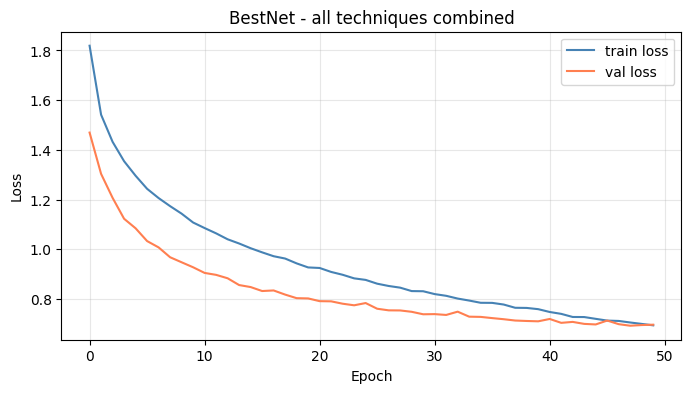

In [28]:
model     = CifarNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

best_val_loss = float('inf')
patience      = 5
no_improve    = 0

wandb.init(project='week12-mnist', config={
    'model': 'CifarNet',
    'dropout': 0.5,
    'lr': 0.0001,
    'scheduler': 'ReduceLROnPlateau'
})

best_train_losses = []
best_val_losses   = []

for epoch in range(50):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)
    best_train_losses.append(train_loss)

    model.eval()
    batch_val = []
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred  = model(X_batch)
            batch_val.append(criterion(pred, y_batch).item())
            preds  = torch.argmax(pred, dim=1)
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)
    val_loss = np.mean(batch_val)
    val_acc  = correct / total
    best_val_losses.append(val_loss)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    wandb.log({'train_loss': train_loss, 'val_loss': val_loss, 'val_accuracy': val_acc})

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f'Epoch {epoch+1}: train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.4f}  lr={current_lr:.6f}  saved')
    else:
        no_improve += 1
        print(f'Epoch {epoch+1}: train={train_loss:.4f}  val={val_loss:.4f}  acc={val_acc:.4f}  lr={current_lr:.6f}  ({no_improve}/{patience})')

    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

model.load_state_dict(torch.load('best_model.pt'))
wandb.finish()

plt.figure(figsize=(8, 4))
plt.plot(best_train_losses, 'steelblue', label='train loss')
plt.plot(best_val_losses,   'coral',     label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BestNet - all techniques combined')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

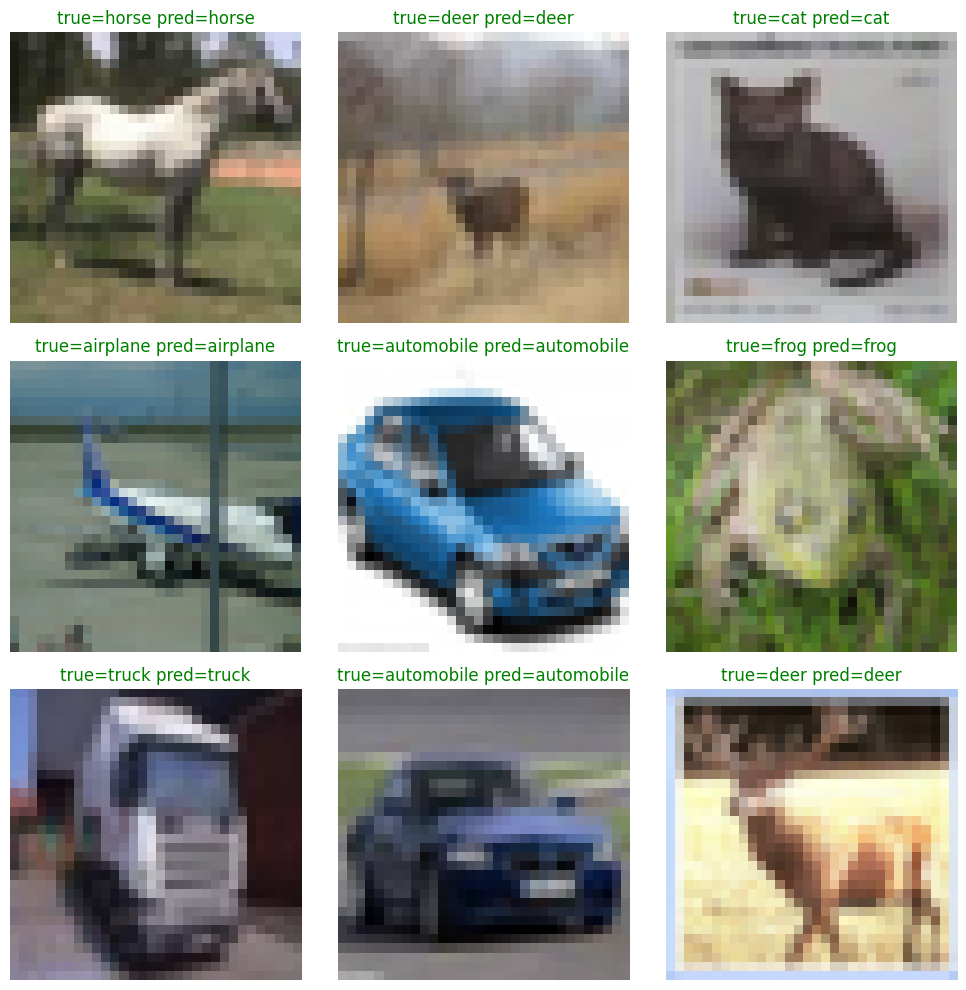

In [36]:
labels = [
    'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'
]

test_loader = DataLoader(test_data, batch_size=64, shuffle=True)
X_batch, y_batch = next(iter(test_loader))   # get one batch of 64 images
X_batch, y_batch = X_batch.to(device), y_batch.to(device)

# run model on the batch
model.eval()
with torch.no_grad():
    logits = model(X_batch)
    preds = torch.argmax(logits, dim=1)

# plot first 9
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_batch[i].cpu().permute(1, 2, 0))
    true  = labels[y_batch[i].item()]
    pred  = labels[preds[i].item()]
    color = 'green' if true == pred else 'red'
    ax.set_title(f'true={true} pred={pred}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# 7. Written answer: CIFAR-10 is harder than MNIST - what accuracy did you get and why do you think color images are harder to classify?
# Final accuracy: ~76%
# Color images are harder because objects have more variation in angle, lighting, and background clutter.
# Classes like cat vs dog or automobile vs truck also look similar.
# MNIST digits are simpler shapes on a clean background with no such ambiguity.